ファイルを読み込みます: G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data/combined_EyeCenterAngle_saccade_analysis_15_4567815161718_umap_nofreq.csv
,区切りファイルとして読み込みます
データ読み込み完了: 177行, 24列
特徴量として使用: 23列
データサイズ: (177, 23)
データの標準化を実行中...
標準化完了
PCAの次元数を23に自動調整しました
PCAによる次元削減を実行中（次元数: 23）...
PCA完了: 累積寄与率 = 1.0000
UMAPによる次元削減を実行中（次元数: 2）...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP次元削減完了


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


クラスター 0: 60 ポイント
クラスター 1: 63 ポイント
クラスター 2: 54 ポイント
プロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_clustered_no_labels.png
IDラベル付きプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_clustered_with_labels.png
クラスター情報付きデータを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_clustered_data.csv


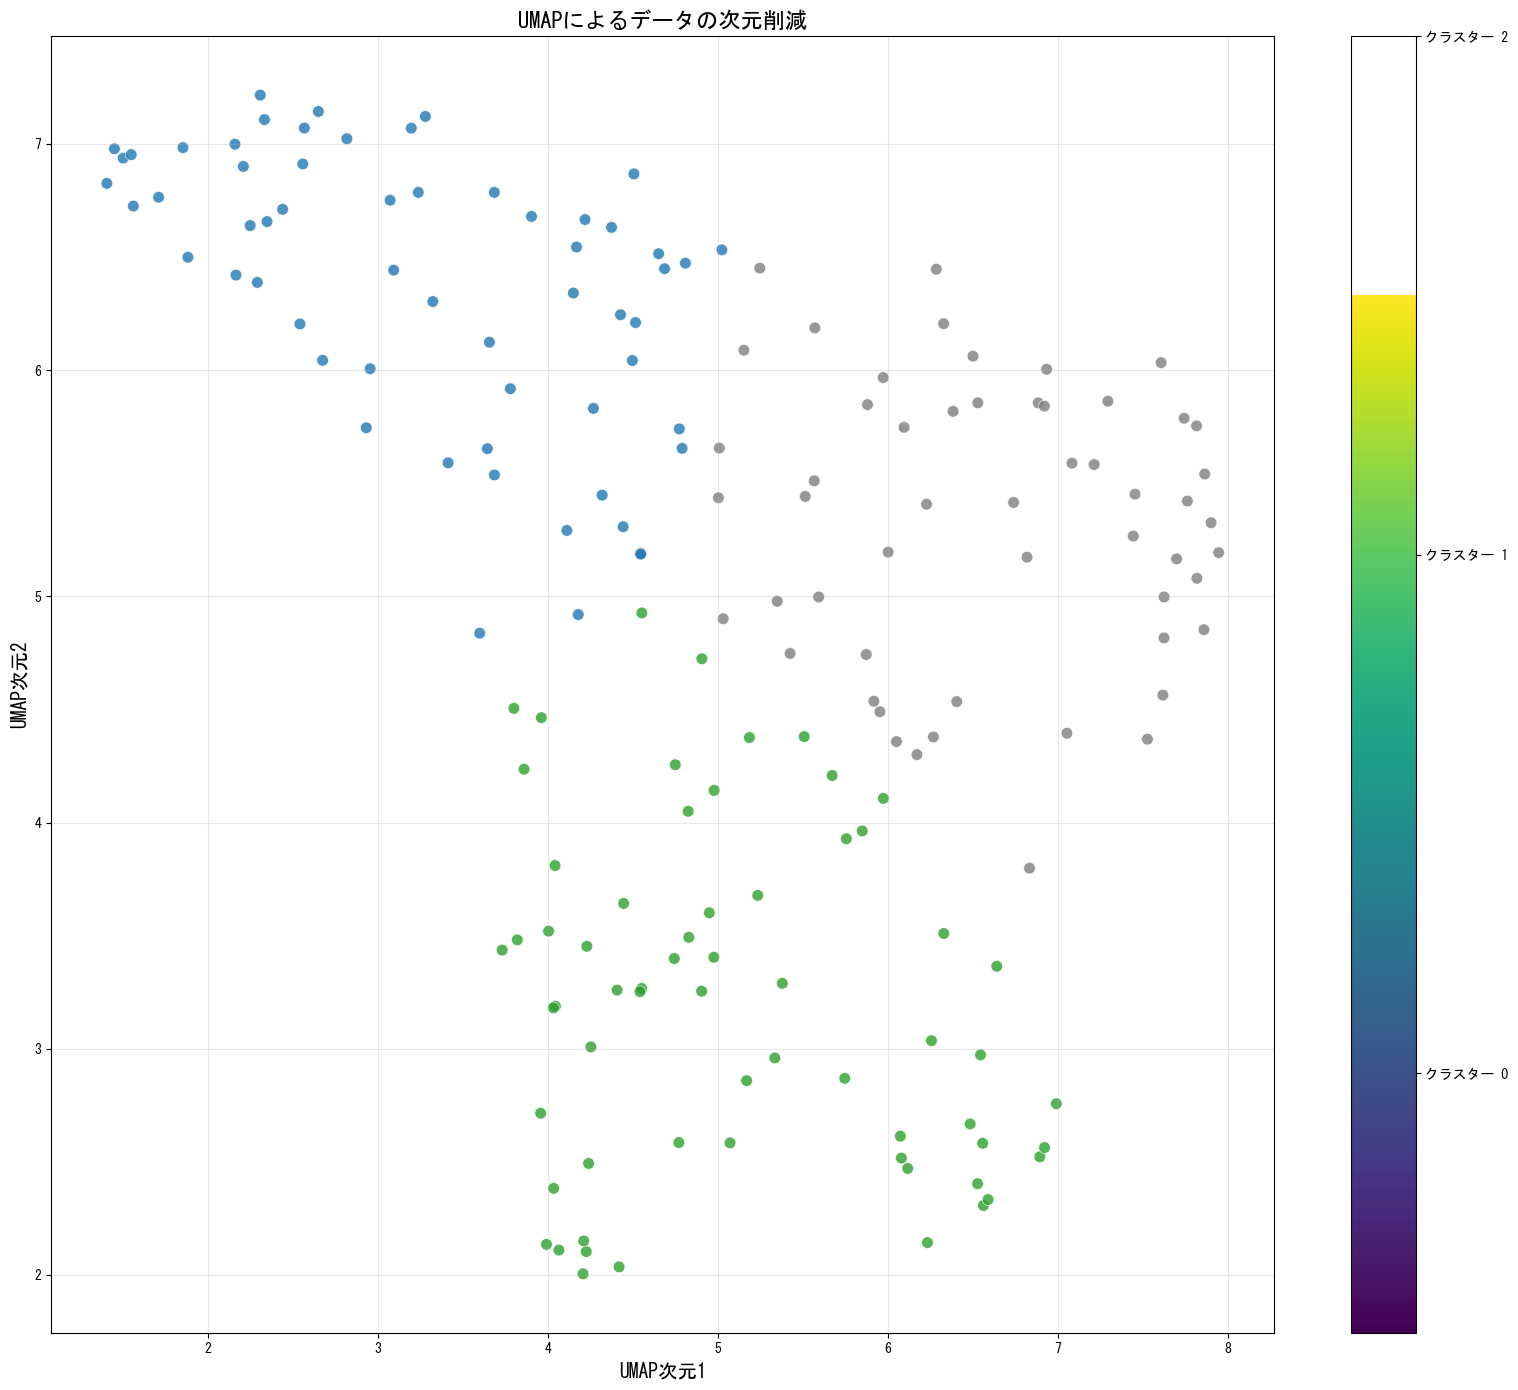

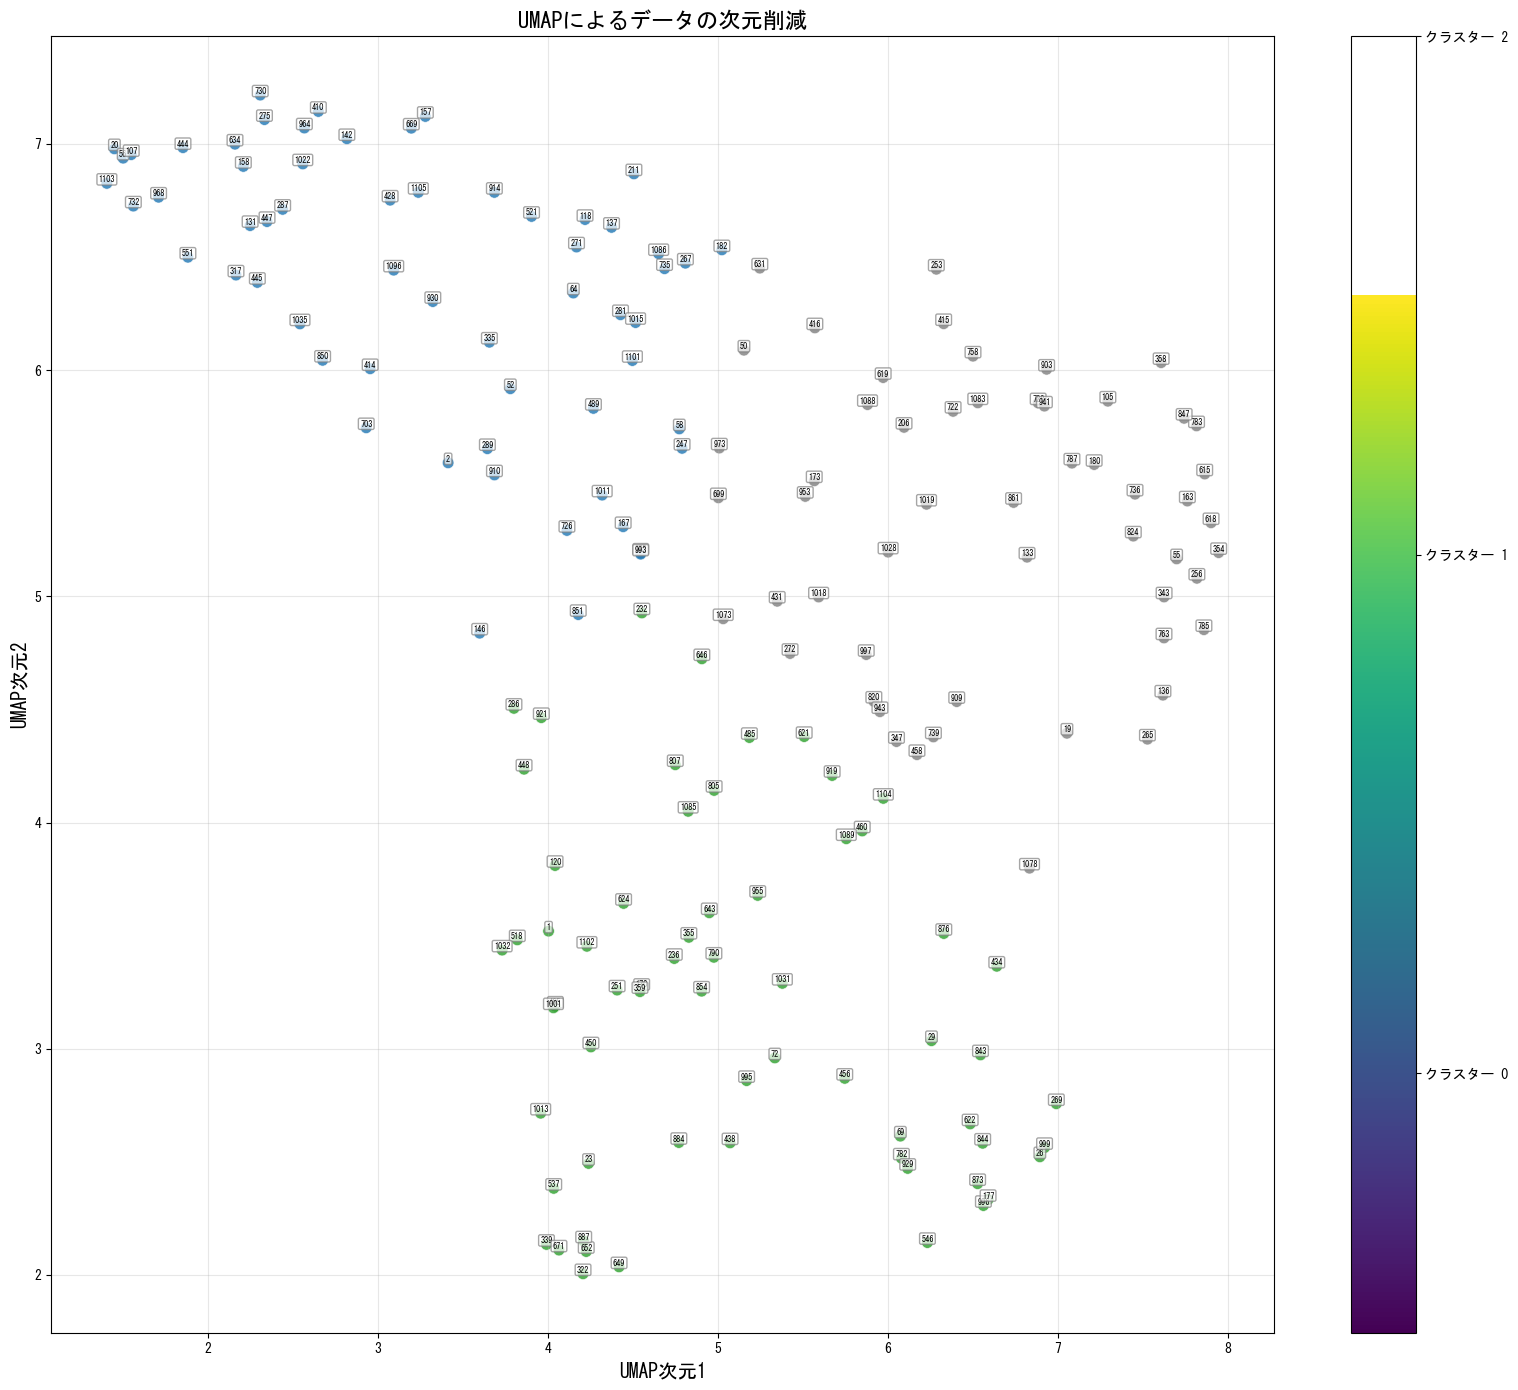

In [1]:
# UMAPによる次元削減とクラスター色分け表示

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.cluster import KMeans
import os

# 日本語フォント設定（必要に応じて）
try:
    import matplotlib.font_manager as fm
    font_path = 'C:/Windows/Fonts/msgothic.ttc'  # Windowsの場合のMSゴシック
    if os.path.exists(font_path):
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rcParams['font.family'] = prop.get_name()
except Exception:
    pass  # フォント設定に失敗しても処理を続行

class DimensionalityReducer:
    """データの次元削減を行うクラス"""
    
    def __init__(self, n_components_pca=None, n_components_umap=2, 
                 umap_n_neighbors=15, umap_min_dist=0.1, random_state=42):
        self.n_components_pca = n_components_pca  # Noneの場合は自動設定
        self.n_components_umap = n_components_umap
        self.umap_n_neighbors = umap_n_neighbors
        self.umap_min_dist = umap_min_dist
        self.random_state = random_state
        
        # モデルは後で初期化
        self.scaler = StandardScaler()
        self.pca = None  # データサイズを確認後に初期化
        self.umap = UMAP(
            n_neighbors=umap_n_neighbors,
            min_dist=umap_min_dist,
            n_components=n_components_umap,
            random_state=random_state
        )
        
        # 変換後のデータ
        self.X_scaled = None
        self.X_pca = None
        self.X_umap = None
        
    def fit_transform(self, X):
        """データに対してPCAとUMAPを適用する"""
        # データの標準化
        print("データの標準化を実行中...")
        self.X_scaled = self.scaler.fit_transform(X)
        print("標準化完了")
        
        # 適切なPCAの次元数を決定
        n_samples, n_features = self.X_scaled.shape
        max_components = min(n_samples, n_features)
        
        if self.n_components_pca is None or self.n_components_pca > max_components:
            # デフォルト値または大きすぎる場合は最大値に設定
            self.n_components_pca = max_components
            print(f"PCAの次元数を{self.n_components_pca}に自動調整しました")
        
        # PCAの初期化と適用
        print(f"PCAによる次元削減を実行中（次元数: {self.n_components_pca}）...")
        self.pca = PCA(n_components=self.n_components_pca, random_state=self.random_state)
        self.X_pca = self.pca.fit_transform(self.X_scaled)
        
        explained_variance_ratio = self.pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance_ratio)
        print(f"PCA完了: 累積寄与率 = {cumulative_variance[-1]:.4f}")
        
        # UMAPの適用
        print(f"UMAPによる次元削減を実行中（次元数: {self.n_components_umap}）...")
        self.X_umap = self.umap.fit_transform(self.X_pca)
        print("UMAP次元削減完了")
        
        return self.X_umap

# データの読み込みと前処理
def load_data(file_path):
    """ファイルを読み込み、前処理を行う"""
    print(f"ファイルを読み込みます: {file_path}")
    
    try:
        # 区切り文字を検出
        with open(file_path, 'r') as f:
            first_line = f.readline().strip()
            
        separator = '\t' if '\t' in first_line else (',' if ',' in first_line else '\t')
        print(f"{separator}区切りファイルとして読み込みます")
        
        # CSVファイルの読み込み
        df = pd.read_csv(file_path, sep=separator)
        print(f"データ読み込み完了: {df.shape[0]}行, {df.shape[1]}列")
        
        # 列が1つだけの場合の処理
        if df.shape[1] == 1:
            print("列が1つだけです。カンマ区切りでの再分割を試みます")
            first_col_name = df.columns[0]
            if ',' in str(df[first_col_name].iloc[0]):
                temp_df = df[first_col_name].str.split(',', expand=True)
                headers = temp_df.iloc[0]
                temp_df = temp_df.iloc[1:]
                temp_df.columns = headers
                df = temp_df
                print("カンマ区切りで再分割しました")
        
        # 数値列に変換
        for col in df.columns:
            if col not in ['freq', 'power_spectrum', 'InspectionDateAndId']:
                try:
                    df[col] = pd.to_numeric(df[col])
                except:
                    pass
        
        # 数値列のみを選択
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
        print(f"特徴量として使用: {len(numeric_cols)}列")
        
        # 特徴量が空の場合はエラー
        if not numeric_cols:
            raise ValueError("数値特徴量が見つかりません")
        
        # 数値データを抽出
        X = df[numeric_cols].copy()
        X = X.fillna(X.mean())  # 欠損値を平均値で補完
        
        return df, X, numeric_cols
        
    except Exception as e:
        print(f"エラー: {str(e)}")
        raise

def plot_clustered_umap(df, embedding, clusters, id_column='InspectionDateAndId', id_type='suffix', 
                         fontsize=8, point_size=70, alpha=0.8, show_labels=True):
    """クラスターで色分けしたUMAP可視化"""
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # クラスターごとに色を設定
    # カラーマップを3つのクラスターに合わせて設定
    colors = ['#1f77b4', '#2ca02c', '#7f7f7f', '#ff7f0e', '#9467bd']  # 青、緑、グレー、オレンジ、紫
    
    # クラスター数に応じて色を繰り返す
    n_clusters = len(np.unique(clusters))
    colors = colors[:n_clusters]  # 必要な色だけ取得
    
    # クラスターごとにポイントを描画（マーカーサイズを大きめに設定）
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=[colors[c] for c in clusters], 
        s=point_size,
        alpha=alpha,
        edgecolor='white',
        linewidth=0.5
    )
    
    # ラベルを表示（オプション）
    if show_labels:
        for i, (x, y) in enumerate(embedding):
            full_id = str(df.iloc[i][id_column])
            
            # IDの処理（表示方法に応じて）
            if id_type == 'suffix' and '_' in full_id:
                # '_'で区切られた末尾の部分を表示
                display_id = full_id.split('_')[-1]
            elif id_type == 'prefix' and '_' in full_id:
                # '_'で区切られた先頭の部分を表示
                display_id = full_id.split('_')[0]
            else:
                # 完全なIDを表示
                display_id = full_id
            
            # テキスト追加（背景を白色に）
            ax.text(
                x, y, 
                display_id,
                fontsize=fontsize,
                ha='center',  # 水平方向の位置揃え
                va='bottom',  # 垂直方向の位置揃え
                bbox=dict(
                    boxstyle="round,pad=0.2",
                    fc="white",
                    ec="gray",
                    alpha=0.7
                )
            )
    
    # カラーバーを追加
    cbar = plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(0, n_clusters-1)), ax=ax)
    cbar.set_ticks(np.arange(n_clusters) + 0.5)
    cbar.set_ticklabels([f'クラスター {i}' for i in range(n_clusters)])
    
    # 軸ラベルとタイトル
    ax.set_xlabel('UMAP次元1', fontsize=14)
    ax.set_ylabel('UMAP次元2', fontsize=14)
    ax.set_title('UMAPによるデータの次元削減', fontsize=16)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# メイン処理
# ファイルパスの設定
path = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data"
file_path = f"{path}/combined_EyeCenterAngle_saccade_analysis_15_4567815161718_umap_nofreq.csv"

# データの読み込みと前処理
df, X, numeric_cols = load_data(file_path)

# データのサイズを確認
print(f"データサイズ: {X.shape}")

# 次元削減の実行 (PCAの次元数は自動調整)
reducer = DimensionalityReducer(n_components_pca=None, n_components_umap=2)
embedding = reducer.fit_transform(X)

# クラスタリングの実行（3クラスタ）
n_clusters = 3  
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embedding)

# クラスター情報をデータフレームに追加
df['cluster'] = clusters
df['umap_x'] = embedding[:, 0]
df['umap_y'] = embedding[:, 1]

# クラスターごとのポイント数をカウント
cluster_counts = np.bincount(clusters)
for i, count in enumerate(cluster_counts):
    print(f"クラスター {i}: {count} ポイント")

# クラスターで色分けしたUMAP可視化（IDラベルなし）
fig, ax = plot_clustered_umap(df, embedding, clusters, show_labels=False)

# 結果を保存
result_path = r"G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result"
os.makedirs(result_path, exist_ok=True)

# プロットを保存
plot_path = os.path.join(result_path, "umap_clustered_no_labels.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"プロットを保存しました: {plot_path}")

# IDラベル付きのプロットも作成
fig2, ax2 = plot_clustered_umap(df, embedding, clusters, show_labels=True, fontsize=6)
plot_path2 = os.path.join(result_path, "umap_clustered_with_labels.png")
plt.savefig(plot_path2, dpi=300, bbox_inches='tight')
print(f"IDラベル付きプロットを保存しました: {plot_path2}")

# データを保存
csv_path = os.path.join(result_path, "umap_clustered_data.csv")
df.to_csv(csv_path, index=False)
print(f"クラスター情報付きデータを保存しました: {csv_path}")

# プロットを表示
plt.show()